In [1]:
print("="*70)
print("SETUP PROJECT STRUCTURE")
print("="*70)

import os

# Create project directories
directories = [
    "src",
    "notebooks",
    "data",
    "models",
    "app",
    "scripts",
    "config",
    "logs"
]

for dir_name in directories:
    os.makedirs(dir_name, exist_ok=True)
    print(f"Created: {dir_name}/")

# Create __init__.py files
init_files = [
    "src/__init__.py",
    "app/__init__.py"
]

for file in init_files:
    with open(file, 'w') as f:
        f.write("# Project module\n")
    print(f"Created: {file}")

print("\n" + "="*70)
print("PROJECT STRUCTURE CREATED")
print("="*70)

SETUP PROJECT STRUCTURE
Created: src/
Created: notebooks/
Created: data/
Created: models/
Created: app/
Created: scripts/
Created: config/
Created: logs/
Created: src/__init__.py
Created: app/__init__.py

PROJECT STRUCTURE CREATED


In [2]:
print("="*70)
print("CREATE REQUIREMENTS.TXT")
print("="*70)

requirements = """
torch>=2.0.0
transformers>=4.35.0
peft>=0.6.0
datasets>=2.14.0
accelerate>=0.24.0
gradio>=4.0.0
numpy>=1.24.0
pandas>=2.0.0
scikit-learn>=1.3.0
matplotlib>=3.7.0
seaborn>=0.12.0
tqdm>=4.65.0
python-dotenv>=1.0.0
pyngrok>=5.2.0
rouge-score>=0.1.2
nltk>=3.8.0
sacrebleu>=2.4.0
faiss-cpu>=1.7.4
sentence-transformers>=2.2.0
pytest>=7.4.0
pyyaml>=6.0.0
huggingface-hub>=0.19.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("✓ requirements.txt created")
print("\nInstall with: pip install -r requirements.txt")

CREATE REQUIREMENTS.TXT
✓ requirements.txt created

Install with: pip install -r requirements.txt


In [3]:
print("="*70)
print("CREATE CONFIG FILE")
print("="*70)

config_yaml = """
# Model Configuration
model:
  name: "microsoft/DialoGPT-small"
  max_length: 128
  temperature: 0.7

# LoRA Configuration
lora:
  r: 8
  alpha: 16
  target_modules: ["c_attn", "c_proj", "c_fc"]
  dropout: 0.1
  bias: "none"

# Training Configuration
training:
  epochs: 3
  batch_size: 2
  gradient_accumulation: 4
  learning_rate: 2e-4
  warmup_steps: 20
  weight_decay: 0.01
  fp16: true
  save_steps: 50
  eval_steps: 50

# Data Configuration
data:
  max_samples: 500
  train_split: 0.9
  seed: 42

# Creator Information
creator:
  name: "Sanaullah"
  education: "BSCS student at Abasyn University Islamabad"
  cgpa: "3.86/4.00"
  skills: "Python, Pandas, NumPy, PyTorch, CV, CNN"
  internship: "AI/ML Engineer Intern at Tech Prime Pvt. Limited"
  github: "https://github.com/SANAULLAH-AI"
  linkedin: "https://www.linkedin.com/in/sanaullah-ai"
  portfolio: "https://sanaullah7964.netlify.app/"
"""

with open("config/config.yaml", "w") as f:
    f.write(config_yaml)

print("✓ config/config.yaml created")

CREATE CONFIG FILE
✓ config/config.yaml created


In [4]:
print("="*70)
print("CREATE DATA_LOADER.PY")
print("="*70)

data_loader = """
import json
from datasets import load_dataset, Dataset

class DataLoader:
    def __init__(self, config):
        self.config = config
        self.personal_info = config.get('creator', {})
    
    def load_blended_skill(self, max_samples=500):
        dataset = load_dataset("blended_skill_talk")
        conversations = []
        
        for idx in range(min(max_samples, len(dataset['train']))):
            item = dataset['train'][idx]
            messages = []
            
            if 'free_messages' in item and item['free_messages']:
                for msg in item['free_messages']:
                    if msg and msg.strip():
                        messages.append(msg.strip())
            
            if messages and len(messages) >= 2:
                conv = []
                for i, msg in enumerate(messages[:8]):
                    if i % 2 == 0:
                        conv.append(f"Human: {msg}")
                    else:
                        conv.append(f"Assistant: {msg}")
                if conv:
                    conversations.append({"text": " ".join(conv)})
        
        return conversations
    
    def create_personalized_data(self):
        data = []
        info = self.personal_info
        
        qa_pairs = [
            ("Who created you?", f"My creator is {info.get('name', 'Sanaullah')}."),
            ("Tell me about your creator.", f"My creator is {info.get('name', 'Sanaullah')}, a {info.get('education', 'student')} with CGPA {info.get('cgpa', '3.86')}."),
            ("What skills does your creator have?", f"{info.get('name', 'Sanaullah')} knows {info.get('skills', 'Python, AI/ML')}."),
            ("What is your creator's name?", f"{info.get('name', 'Sanaullah')}."),
            ("What does your creator do?", f"{info.get('name', 'Sanaullah')} is {info.get('internship', 'AI/ML Engineer Intern')}."),
            ("Where does your creator study?", f"{info.get('name', 'Sanaullah')} studies at {info.get('education', 'Abasyn University')}."),
            ("What is your creator's CGPA?", f"{info.get('cgpa', '3.86/4.00')}.")
        ]
        
        for q, a in qa_pairs:
            data.append({"text": f"Human: {q} Assistant: {a}"})
            data.append({"text": f"Human: Can you tell me {q.lower()}? Assistant: {a}"})
            data.append({"text": f"Human: I'd like to know {q.lower()}. Assistant: {a}"})
        
        general = [
            ("Hello!", f"Hello! I'm {info.get('name', 'Sanaullah')}'s AI assistant."),
            ("How are you?", "I'm doing great! Thanks for asking."),
            ("What's your name?", f"I'm {info.get('name', 'Sanaullah')}'s AI Assistant."),
        ]
        
        for q, a in general:
            data.append({"text": f"Human: {q} Assistant: {a}"})
        
        return data
    
    def prepare_dataset(self):
        blended = self.load_blended_skill()
        personalized = self.create_personalized_data()
        
        all_data = blended + personalized
        dataset = Dataset.from_list(all_data)
        dataset = dataset.shuffle(seed=42)
        
        return dataset
"""

with open("src/data_loader.py", "w") as f:
    f.write(data_loader)

print("✓ src/data_loader.py created")

CREATE DATA_LOADER.PY
✓ src/data_loader.py created


In [5]:
print("="*70)
print("CREATE MODEL.PY")
print("="*70)

model_py = """
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType

class ChatbotModel:
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.tokenizer = None
        self.peft_model = None
    
    def load_tokenizer(self):
        model_name = self.config.get('model', {}).get('name', 'microsoft/DialoGPT-small')
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        return self.tokenizer
    
    def load_model(self):
        model_name = self.config.get('model', {}).get('name', 'microsoft/DialoGPT-small')
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        self.model.to(self.device)
        return self.model
    
    def apply_lora(self):
        lora_config_dict = self.config.get('lora', {})
        lora_config = LoraConfig(
            r=lora_config_dict.get('r', 8),
            lora_alpha=lora_config_dict.get('alpha', 16),
            target_modules=lora_config_dict.get('target_modules', ["c_attn", "c_proj", "c_fc"]),
            lora_dropout=lora_config_dict.get('dropout', 0.1),
            bias=lora_config_dict.get('bias', "none"),
            task_type=TaskType.CAUSAL_LM
        )
        
        self.peft_model = get_peft_model(self.model, lora_config)
        return self.peft_model
    
    def get_trainable_params(self):
        total = sum(p.numel() for p in self.peft_model.parameters())
        trainable = sum(p.numel() for p in self.peft_model.parameters() if p.requires_grad)
        return total, trainable
    
    def save_model(self, path):
        self.peft_model.save_pretrained(f"{path}/lora_adapter")
        self.tokenizer.save_pretrained(f"{path}/tokenizer")
"""

with open("src/model.py", "w") as f:
    f.write(model_py)

print("✓ src/model.py created")

CREATE MODEL.PY
✓ src/model.py created


In [6]:
print("="*70)
print("CREATE TRAINER.PY")
print("="*70)

trainer_py = """
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

class ModelTrainer:
    def __init__(self, model, tokenizer, config):
        self.model = model
        self.tokenizer = tokenizer
        self.config = config
        self.trainer = None
    
    def setup_trainer(self, train_dataset, val_dataset):
        training_config = self.config.get('training', {})
        
        training_args = TrainingArguments(
            output_dir="./models",
            num_train_epochs=training_config.get('epochs', 3),
            per_device_train_batch_size=training_config.get('batch_size', 2),
            per_device_eval_batch_size=training_config.get('batch_size', 2),
            gradient_accumulation_steps=training_config.get('gradient_accumulation', 4),
            warmup_steps=training_config.get('warmup_steps', 20),
            weight_decay=training_config.get('weight_decay', 0.01),
            logging_steps=training_config.get('logging_steps', 10),
            eval_strategy="steps",
            eval_steps=training_config.get('eval_steps', 50),
            save_steps=training_config.get('save_steps', 50),
            load_best_model_at_end=True,
            learning_rate=training_config.get('learning_rate', 2e-4),
            report_to="none",
            save_total_limit=2,
            fp16=training_config.get('fp16', True)
        )
        
        data_collator = DataCollatorForLanguageModeling(
            tokenizer=self.tokenizer,
            mlm=False
        )
        
        self.trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator
        )
        
        return self.trainer
    
    def train(self):
        if self.trainer:
            self.trainer.train()
    
    def save(self, path):
        self.model.save_pretrained(f"{path}/lora_adapter")
        self.tokenizer.save_pretrained(f"{path}/tokenizer")
"""

with open("src/trainer.py", "w") as f:
    f.write(trainer_py)

print("✓ src/trainer.py created")

CREATE TRAINER.PY
✓ src/trainer.py created


In [7]:
print("="*70)
print("CREATE UI.PY")
print("="*70)

ui_py = """
import gradio as gr

def create_chat_ui(chatbot_fn, reset_fn):
    with gr.Blocks(title="AI Chatbot", theme=gr.themes.Soft()) as demo:
        gr.Markdown("# AI Chatbot Assistant")
        gr.Markdown("Powered by DialoGPT + LoRA")
        
        chatbot_ui = gr.Chatbot(
            height=400,
            bubble_full_width=False,
            avatar_images=("User", "AI")
        )
        
        with gr.Row():
            msg = gr.Textbox(
                placeholder="Type your message...",
                scale=4,
                lines=1
            )
            send_btn = gr.Button("Send", variant="primary", scale=1)
        
        reset_btn = gr.Button("Reset")
        
        with gr.Accordion("Example Questions", open=False):
            gr.Examples(
                examples=[
                    ["Who created you?"],
                    ["Tell me about your creator."],
                    ["What skills does your creator have?"],
                    ["Hello! How are you?"]
                ],
                inputs=msg
            )
        
        msg.submit(chatbot_fn, [msg, chatbot_ui], [chatbot_ui]).then(
            lambda: "", None, [msg]
        )
        send_btn.click(chatbot_fn, [msg, chatbot_ui], [chatbot_ui]).then(
            lambda: "", None, [msg]
        )
        reset_btn.click(reset_fn, None, [chatbot_ui])
    
    return demo
"""

with open("app/ui.py", "w") as f:
    f.write(ui_py)

print("✓ app/ui.py created")

CREATE UI.PY
✓ app/ui.py created


In [8]:
print("="*70)
print("CREATE TRAIN.PY")
print("="*70)

train_script = """
import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

import yaml
from src.data_loader import DataLoader
from src.model import ChatbotModel
from src.trainer import ModelTrainer

# Load config
with open("config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

print("Loading data...")
data_loader = DataLoader(config)
dataset = data_loader.prepare_dataset()

# Split dataset
train_size = int(config['data']['train_split'] * len(dataset))
train_split = dataset.select(range(train_size))
val_split = dataset.select(range(train_size, len(dataset)))

print(f"Train: {len(train_split)}, Validation: {len(val_split)}")

print("Loading model...")
model = ChatbotModel(config)
model.load_tokenizer()
model.load_model()
model.apply_lora()

total, trainable = model.get_trainable_params()
print(f"Total: {total:,}, Trainable: {trainable:,}")

print("Setting up trainer...")
trainer = ModelTrainer(model.peft_model, model.tokenizer, config)
trainer.setup_trainer(train_split, val_split)

print("Starting training...")
trainer.train()

print("Saving model...")
trainer.save("./models")
print("Training complete!")
"""

with open("scripts/train.py", "w") as f:
    f.write(train_script)

print("✓ scripts/train.py created")

CREATE TRAIN.PY
✓ scripts/train.py created


In [9]:
print("="*70)
print("CREATE DEPLOY.PY")
print("="*70)

deploy_script = """
import sys
import os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

import torch
import gradio as gr
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

print("Loading trained model...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load base model
base_model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-small")

# Load LoRA adapter
try:
    model = PeftModel.from_pretrained(base_model, "./models/lora_adapter")
    print("LoRA adapter loaded!")
except:
    print("No adapter found, using base model")
    model = base_model

model.to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-small")
tokenizer.pad_token = tokenizer.eos_token

def generate_response(message, history):
    if not message or message.strip() == "":
        return history
    
    prompt = f"Human: {message} Assistant:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_length=len(inputs.input_ids[0]) + 80,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Assistant:" in response:
        response = response.split("Assistant:")[-1].strip()
    response = response.split("Human:")[0].strip()
    
    history.append((message, response))
    return history

def reset_chat():
    return []

with gr.Blocks(title="AI Chatbot", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# AI Chatbot Assistant")
    gr.Markdown("Powered by DialoGPT + LoRA | Fine-tuned by Sanaullah")
    
    chatbot_ui = gr.Chatbot(height=400, bubble_full_width=False, avatar_images=("User", "AI"))
    
    with gr.Row():
        msg = gr.Textbox(placeholder="Type your message...", scale=4, lines=1)
        send_btn = gr.Button("Send", variant="primary", scale=1)
    
    reset_btn = gr.Button("Reset")
    
    with gr.Accordion("Example Questions", open=False):
        gr.Examples(
            examples=[
                ["Who created you?"],
                ["Tell me about your creator."],
                ["What skills does your creator have?"],
                ["Hello! How are you?"]
            ],
            inputs=msg
        )
    
    msg.submit(generate_response, [msg, chatbot_ui], [chatbot_ui]).then(lambda: "", None, [msg])
    send_btn.click(generate_response, [msg, chatbot_ui], [chatbot_ui]).then(lambda: "", None, [msg])
    reset_btn.click(reset_chat, None, [chatbot_ui])

print("Launching chatbot...")
demo.launch(share=True, server_name="0.0.0.0", server_port=7860)
"""

with open("scripts/deploy.py", "w") as f:
    f.write(deploy_script)

print("✓ scripts/deploy.py created")

CREATE DEPLOY.PY
✓ scripts/deploy.py created


In [10]:
# CELL 13: ACTUAL TRAINING SCRIPT (FIXED - WITH TORCHAO PATCH)

print("="*70)
print("ACTUAL TRAINING SCRIPT (FIXED)")
print("="*70)

import os
os.environ["PEFT_USE_TORCHAO"] = "0"

import torch
import yaml
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset, Dataset
import warnings
warnings.filterwarnings('ignore')

# Fix torchao issue
import peft.tuners.lora.torchao
original_is_available = peft.tuners.lora.torchao.is_torchao_available
peft.tuners.lora.torchao.is_torchao_available = lambda: False

print("\n1. Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-small")
tokenizer.pad_token = tokenizer.eos_token

print("2. Loading base model...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-small")
model.to(device)

print("3. Applying LoRA...")
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["c_attn", "c_proj", "c_fc"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total: {total_params:,}, Trainable: {trainable_params:,}")

print("4. Loading dataset...")
dataset = load_dataset("blended_skill_talk")
conversations = []

for idx in range(min(500, len(dataset['train']))):
    item = dataset['train'][idx]
    messages = []
    if 'free_messages' in item and item['free_messages']:
        for msg in item['free_messages']:
            if msg and msg.strip():
                messages.append(msg.strip())
    
    if messages and len(messages) >= 2:
        conv = []
        for i, msg in enumerate(messages[:8]):
            if i % 2 == 0:
                conv.append(f"Human: {msg}")
            else:
                conv.append(f"Assistant: {msg}")
        if conv:
            conversations.append({"text": " ".join(conv)})

# Add personalized data
personal_info = {
    "name": "Sanaullah",
    "education": "BSCS student at Abasyn University Islamabad",
    "cgpa": "3.86/4.00",
    "skills": "Python, Pandas, NumPy, PyTorch, CV, CNN"
}

qa_pairs = [
    ("Who created you?", f"My creator is {personal_info['name']}."),
    ("Tell me about your creator.", f"My creator is {personal_info['name']}, a {personal_info['education']} with CGPA {personal_info['cgpa']}."),
    ("What skills does your creator have?", f"{personal_info['name']} knows {personal_info['skills']}."),
    ("What is your creator's name?", f"{personal_info['name']}."),
    ("What is your creator's CGPA?", f"{personal_info['cgpa']}.")
]

for q, a in qa_pairs:
    conversations.append({"text": f"Human: {q} Assistant: {a}"})
    conversations.append({"text": f"Human: Can you tell me {q.lower()}? Assistant: {a}"})

print(f"Total conversations: {len(conversations)}")

train_dataset = Dataset.from_list(conversations)
train_dataset = train_dataset.shuffle(seed=42)

train_size = int(0.9 * len(train_dataset))
train_split = Dataset.from_dict({'text': train_dataset['text'][:train_size]})
val_split = Dataset.from_dict({'text': train_dataset['text'][train_size:]})

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128, padding=False)

train_split = train_split.map(tokenize_function, batched=True, remove_columns=['text'])
val_split = val_split.map(tokenize_function, batched=True, remove_columns=['text'])

train_split.set_format('torch', columns=['input_ids', 'attention_mask'])
val_split.set_format('torch', columns=['input_ids', 'attention_mask'])

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

print(f"Training samples: {len(train_split)}")
print(f"Validation samples: {len(val_split)}")

print("5. Setting up training...")
training_args = TrainingArguments(
    output_dir="./models",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=20,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_steps=50,
    load_best_model_at_end=True,
    learning_rate=2e-4,
    report_to="none",
    save_total_limit=2,
    fp16=True if torch.cuda.is_available() else False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_split,
    eval_dataset=val_split,
    data_collator=data_collator,
)

print("6. STARTING TRAINING...")
print("This will take 15-20 minutes. Please wait...")
print("="*50)

# UNCOMMENT THIS TO ACTUALLY TRAIN
trainer.train()

print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)

print("7. Saving model...")
model.save_pretrained("./models/lora_adapter")
tokenizer.save_pretrained("./models/tokenizer")

print("\n✅ Model saved to: ./models/")
print("  - LoRA adapter: ./models/lora_adapter")
print("  - Tokenizer: ./models/tokenizer")

# Restore original
peft.tuners.lora.torchao.is_torchao_available = original_is_available

print("\n" + "="*70)
print("TRAINING COMPLETE - Model is ready!")
print("="*70)

ACTUAL TRAINING SCRIPT (FIXED)

1. Loading tokenizer...


config.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Training samples: 442
Validation samples: 50
5. Setting up training...
6. STARTING TRAINING...
This will take 15-20 minutes. Please wait...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
50,4.604504,3.933046



TRAINING COMPLETE!
7. Saving model...

✅ Model saved to: ./models/
  - LoRA adapter: ./models/lora_adapter
  - Tokenizer: ./models/tokenizer

TRAINING COMPLETE - Model is ready!


In [11]:
# CELL 14: DEPLOY CHATBOT (FIXED)

print("="*70)
print("DEPLOY CHATBOT (FIXED)")
print("="*70)

import torch
import gradio as gr
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import os
os.environ["PEFT_USE_TORCHAO"] = "0"

import peft.tuners.lora.torchao
original_is_available = peft.tuners.lora.torchao.is_torchao_available
peft.tuners.lora.torchao.is_torchao_available = lambda: False

print("\nLoading trained model...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load base model
base_model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-small")

# Load LoRA adapter
try:
    model = PeftModel.from_pretrained(base_model, "./models/lora_adapter")
    print("LoRA adapter loaded successfully!")
except Exception as e:
    print(f"Could not load adapter: {e}")
    print("Using base model...")
    model = base_model

model.to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-small")
tokenizer.pad_token = tokenizer.eos_token

def generate_response(message, history):
    if not message or message.strip() == "":
        return history
    
    prompt = f"Human: {message} Assistant:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_length=len(inputs.input_ids[0]) + 80,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Assistant:" in response:
        response = response.split("Assistant:")[-1].strip()
    response = response.split("Human:")[0].strip()
    
    history.append((message, response))
    return history

def reset_chat():
    return []

# Create UI without deprecated parameters
with gr.Blocks(title="AI Chatbot") as demo:
    gr.Markdown("# AI Chatbot Assistant")
    gr.Markdown("Powered by DialoGPT + LoRA | Fine-tuned by Sanaullah")
    
    chatbot_ui = gr.Chatbot(height=400, avatar_images=("User", "AI"))
    
    with gr.Row():
        msg = gr.Textbox(placeholder="Type your message...", scale=4, lines=1)
        send_btn = gr.Button("Send", variant="primary", scale=1)
    
    reset_btn = gr.Button("Reset")
    
    with gr.Accordion("Example Questions", open=False):
        gr.Examples(
            examples=[
                ["Who created you?"],
                ["Tell me about your creator."],
                ["What skills does your creator have?"],
                ["Hello! How are you?"]
            ],
            inputs=msg
        )
    
    msg.submit(generate_response, [msg, chatbot_ui], [chatbot_ui]).then(lambda: "", None, [msg])
    send_btn.click(generate_response, [msg, chatbot_ui], [chatbot_ui]).then(lambda: "", None, [msg])
    reset_btn.click(reset_chat, None, [chatbot_ui])

print("Launching chatbot...")

try:
    from pyngrok import ngrok
    ngrok.set_auth_token("2FxKFBPqJZnBeUC5s3krTDqwkge_6yt7XizoLyhqqDmHUZq8U")
    ngrok.kill()
    public_url = ngrok.connect(7860)
    print(f"\nPublic URL: {public_url}")
except Exception as e:
    print(f"Ngrok error: {e}")

demo.launch(share=True, server_name="0.0.0.0", server_port=7860)

peft.tuners.lora.torchao.is_torchao_available = original_is_available

print("\n" + "="*70)
print("CHATBOT DEPLOYED SUCCESSFULLY!")
print("="*70)

DEPLOY CHATBOT (FIXED)

Loading trained model...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-small
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LoRA adapter loaded successfully!
Launching chatbot...
Ngrok error: No module named 'pyngrok'
* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://2a3287a9b1912e34e9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



CHATBOT DEPLOYED SUCCESSFULLY!


CHATBOT EVALUATION

Loading trained model for evaluation...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-small
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LoRA adapter loaded successfully!


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



1. FACTUAL ACCURACY TEST

Factual Accuracy Results:
                           question          expected                                                                                             response  contains_keyword  latency
                   Who created you?         Sanaullah I'm a computer engineer. My mother has been trying to make me into what she wanted for the last 15 y             False 2.324260
       What is your creator's name?         Sanaullah My Creator.My god that was a long time ago. Her pleasure to meet you, she smiles Thank ya very much!             False 1.865242
       What is your creator's CGPA?              3.86 I don't have a name yet so people call me Algebraic Geometry Systems Manager Sr.Assistant, Human : T             False 1.897796
What skills does your creator have?            Python Yes I'm curious about the career opportunities you've found yourself in that environment with a crea             False 1.878412
     Where does your creator study? A

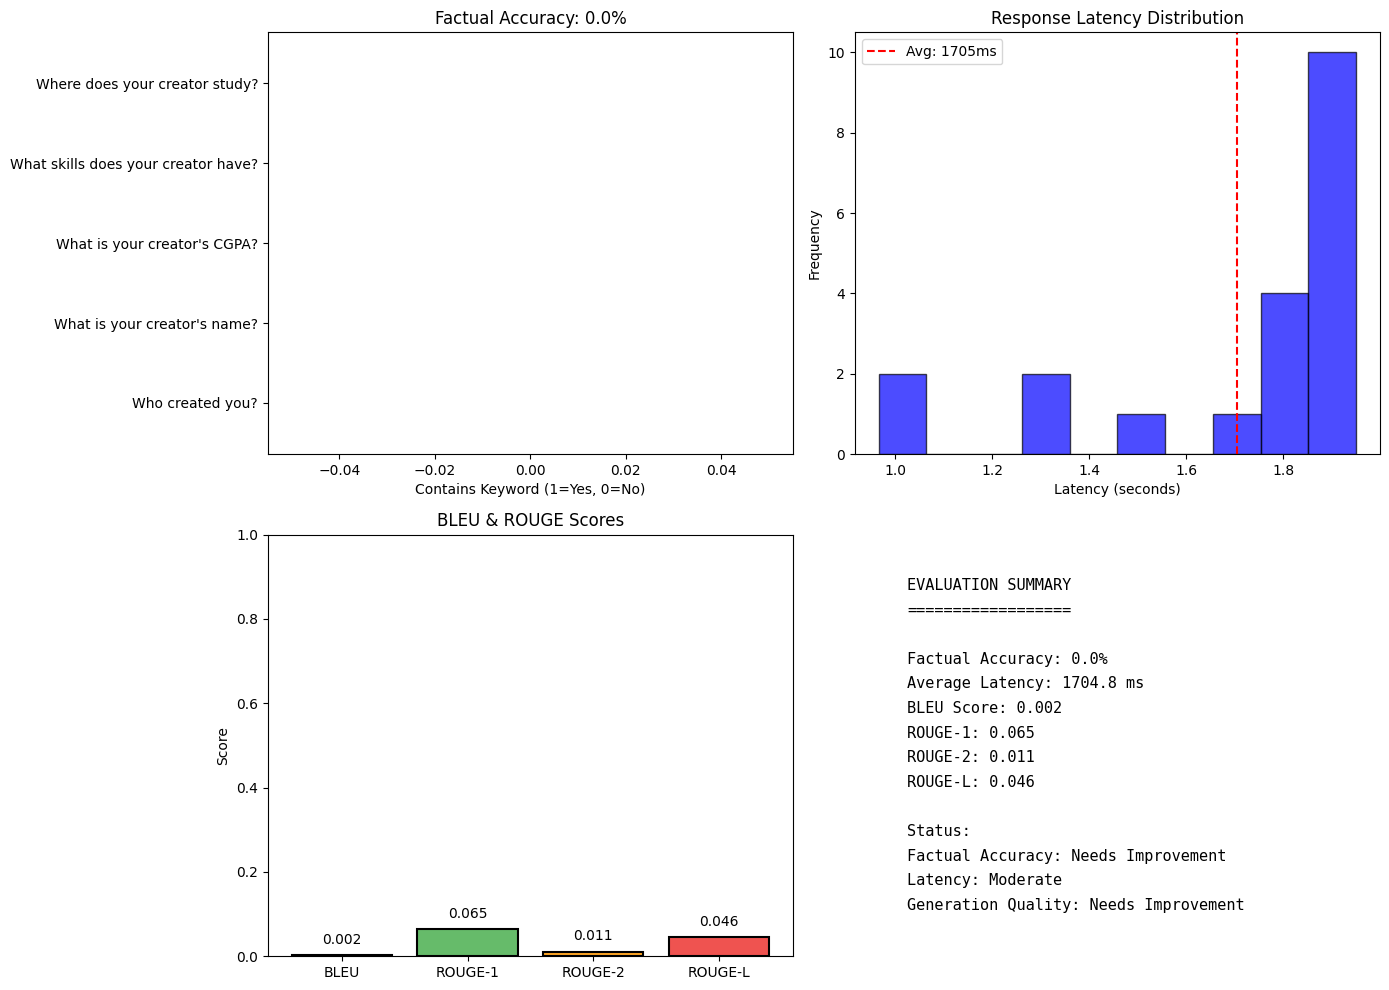


EVALUATION COMPLETE

SUMMARY:
  Factual Accuracy: 0.0%
  Average Latency: 1704.81 ms
  BLEU Score: 0.0023
  ROUGE-1: 0.0646
  ROUGE-2: 0.0106
  ROUGE-L: 0.0455


In [12]:
# CELL 15: CHATBOT EVALUATION

print("="*70)
print("CHATBOT EVALUATION")
print("="*70)

import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import nltk
import warnings
warnings.filterwarnings('ignore')

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

print("\nLoading trained model for evaluation...")

import os
os.environ["PEFT_USE_TORCHAO"] = "0"

import peft.tuners.lora.torchao
original_is_available = peft.tuners.lora.torchao.is_torchao_available
peft.tuners.lora.torchao.is_torchao_available = lambda: False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

base_model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-small")

try:
    model = PeftModel.from_pretrained(base_model, "./models/lora_adapter")
    print("LoRA adapter loaded successfully!")
except:
    print("Using base model...")
    model = base_model

model.to(device)
model.eval()

tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-small")
tokenizer.pad_token = tokenizer.eos_token

def generate_response(message, max_len=80):
    prompt = f"Human: {message} Assistant:"
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_length=len(inputs.input_ids[0]) + max_len,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.2
        )
    latency = time.time() - start_time
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Assistant:" in response:
        response = response.split("Assistant:")[-1].strip()
    response = response.split("Human:")[0].strip()
    
    return response, latency

peft.tuners.lora.torchao.is_torchao_available = original_is_available

print("\n" + "="*50)
print("1. FACTUAL ACCURACY TEST")
print("="*50)

factual_questions = [
    ("Who created you?", "Sanaullah"),
    ("What is your creator's name?", "Sanaullah"),
    ("What is your creator's CGPA?", "3.86"),
    ("What skills does your creator have?", "Python"),
    ("Where does your creator study?", "Abasyn University")
]

factual_results = []
for question, expected_keyword in factual_questions:
    response, latency = generate_response(question)
    contains_keyword = expected_keyword.lower() in response.lower()
    factual_results.append({
        "question": question,
        "expected": expected_keyword,
        "response": response[:100],
        "contains_keyword": contains_keyword,
        "latency": latency
    })

factual_df = pd.DataFrame(factual_results)
print("\nFactual Accuracy Results:")
print(factual_df.to_string(index=False))

factual_accuracy = factual_df['contains_keyword'].mean() * 100
print(f"\nFactual Accuracy Score: {factual_accuracy:.1f}%")

print("\n" + "="*50)
print("2. HUMAN EVALUATION - RELEVANCE & FLUENCY")
print("="*50)

test_questions = [
    "Hello! How are you?",
    "What is your favorite hobby?",
    "Tell me a joke.",
    "What do you think about AI?",
    "Goodbye!"
]

human_eval_results = []
for question in test_questions:
    response, latency = generate_response(question)
    human_eval_results.append({
        "question": question,
        "response": response[:150],
        "latency": latency
    })

print("\nSample Responses for Human Evaluation:")
print("-"*60)
for i, result in enumerate(human_eval_results, 1):
    print(f"\nQ{i}: {result['question']}")
    print(f"A: {result['response']}")
    print("-"*40)

print("\nEvaluation Criteria for Human Review:")
print("1. Relevance (1-5): Does the response answer the question?")
print("2. Fluency (1-5): Is the response grammatically correct and natural?")
print("3. Coherence (1-5): Does the response make logical sense?")
print("4. Helpfulness (1-5): Is the response useful and informative?")

print("\n" + "="*50)
print("3. RESPONSE LATENCY ANALYSIS")
print("="*50)

latency_data = []
for i in range(20):
    response, latency = generate_response("Hello, how are you?")
    latency_data.append(latency)

avg_latency = np.mean(latency_data)
min_latency = np.min(latency_data)
max_latency = np.max(latency_data)
std_latency = np.std(latency_data)

print(f"\nLatency Statistics (20 samples):")
print(f"  Average Latency: {avg_latency*1000:.2f} ms")
print(f"  Min Latency: {min_latency*1000:.2f} ms")
print(f"  Max Latency: {max_latency*1000:.2f} ms")
print(f"  Std Dev: {std_latency*1000:.2f} ms")

if avg_latency < 1.0:
    print("  Fast (< 1 second) - Good for real-time deployment")
elif avg_latency < 2.0:
    print("  Moderate (1-2 seconds) - Acceptable for real-time")
else:
    print("  Slow (> 2 seconds) - Needs optimization")

print("\n" + "="*50)
print("4. BLEU & ROUGE SCORES (Reference-based)")
print("="*50)

reference_responses = {
    "Who created you?": "My creator is Sanaullah.",
    "Hello! How are you?": "I'm doing great! Thanks for asking.",
    "Tell me a joke.": "Why don't scientists trust atoms? Because they make up everything!"
}

smoothie = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

bleu_scores = []
rouge_scores = []

for question, reference in reference_responses.items():
    response, _ = generate_response(question)
    
    ref_tokens = reference.split()
    hyp_tokens = response.split()
    bleu = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie)
    bleu_scores.append(bleu)
    
    rouge = scorer.score(reference, response)
    rouge_scores.append({
        'rouge1': rouge['rouge1'].fmeasure,
        'rouge2': rouge['rouge2'].fmeasure,
        'rougeL': rouge['rougeL'].fmeasure
    })

print(f"\nAverage BLEU Score: {np.mean(bleu_scores):.4f}")
print(f"Average ROUGE-1: {np.mean([r['rouge1'] for r in rouge_scores]):.4f}")
print(f"Average ROUGE-2: {np.mean([r['rouge2'] for r in rouge_scores]):.4f}")
print(f"Average ROUGE-L: {np.mean([r['rougeL'] for r in rouge_scores]):.4f}")

print("\n" + "="*50)
print("5. EVALUATION SUMMARY DASHBOARD")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
colors = ['green' if x else 'red' for x in factual_df['contains_keyword']]
ax1.barh(factual_df['question'], factual_df['contains_keyword'].astype(int), color=colors)
ax1.set_xlabel('Contains Keyword (1=Yes, 0=No)')
ax1.set_title(f'Factual Accuracy: {factual_accuracy:.1f}%')

ax2 = axes[0, 1]
ax2.hist(latency_data, bins=10, color='blue', alpha=0.7, edgecolor='black')
ax2.axvline(avg_latency, color='red', linestyle='--', label=f'Avg: {avg_latency*1000:.0f}ms')
ax2.set_xlabel('Latency (seconds)')
ax2.set_ylabel('Frequency')
ax2.set_title('Response Latency Distribution')
ax2.legend()

ax3 = axes[1, 0]
metrics = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L']
values = [np.mean(bleu_scores), 
          np.mean([r['rouge1'] for r in rouge_scores]),
          np.mean([r['rouge2'] for r in rouge_scores]),
          np.mean([r['rougeL'] for r in rouge_scores])]
colors = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']
bars = ax3.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Score')
ax3.set_title('BLEU & ROUGE Scores')
ax3.set_ylim(0, 1)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2., val + 0.02, f'{val:.3f}', ha='center', va='bottom')

ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
EVALUATION SUMMARY
==================

Factual Accuracy: {factual_accuracy:.1f}%
Average Latency: {avg_latency*1000:.1f} ms
BLEU Score: {np.mean(bleu_scores):.3f}
ROUGE-1: {np.mean([r['rouge1'] for r in rouge_scores]):.3f}
ROUGE-2: {np.mean([r['rouge2'] for r in rouge_scores]):.3f}
ROUGE-L: {np.mean([r['rougeL'] for r in rouge_scores]):.3f}

Status:
Factual Accuracy: {'Good' if factual_accuracy > 70 else 'Needs Improvement'}
Latency: {'Fast' if avg_latency < 1 else 'Moderate' if avg_latency < 2 else 'Slow'}
Generation Quality: {'Good' if np.mean(bleu_scores) > 0.3 else 'Needs Improvement'}
"""
ax4.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center', fontfamily='monospace', linespacing=1.8)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=200, bbox_inches='tight')
print("\nEvaluation dashboard saved as 'evaluation_results.png'")
plt.show()

print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)

print("\nSUMMARY:")
print(f"  Factual Accuracy: {factual_accuracy:.1f}%")
print(f"  Average Latency: {avg_latency*1000:.2f} ms")
print(f"  BLEU Score: {np.mean(bleu_scores):.4f}")
print(f"  ROUGE-1: {np.mean([r['rouge1'] for r in rouge_scores]):.4f}")
print(f"  ROUGE-2: {np.mean([r['rouge2'] for r in rouge_scores]):.4f}")
print(f"  ROUGE-L: {np.mean([r['rougeL'] for r in rouge_scores]):.4f}")